<a href="https://colab.research.google.com/github/SurangaMadushan/pytorch-deep-learning-project/blob/main/notebooks/04_cats_vs_dogs_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import userdata

kaggle_token = userdata.get("KAGGLE_API_TOKEN")

print("Token loaded successfully!" if kaggle_token else "Token not found!")

Token loaded successfully!


In [6]:
import os
from google.colab import userdata

kaggle_token = userdata.get("KAGGLE_API_TOKEN").strip()

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

print("Token Length:", len(kaggle_token))

Token Length: 37


In [7]:
!kaggle --version

Kaggle CLI 2.0.2


In [8]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:07<00:00, 29.9MB/s]



In [9]:
!unzip -q cat-and-dog.zip -d data

In [10]:
import os

print(os.listdir("data"))

['test_set', 'training_set']


In [11]:
import os

train_dir = "data/training_set/training_set"
test_dir = "data/test_set/test_set"

print(os.listdir(train_dir))
print(os.listdir(test_dir))

['cats', 'dogs']
['cats', 'dogs']


In [12]:
train_cats = len(os.listdir(train_dir + "/cats"))
train_dogs = len(os.listdir(train_dir + "/dogs"))

test_cats = len(os.listdir(test_dir + "/cats"))
test_dogs = len(os.listdir(test_dir + "/dogs"))

print("Training Cats :", train_cats)
print("Training Dogs :", train_dogs)

print()

print("Testing Cats :", test_cats)
print("Testing Dogs :", test_dogs)

Training Cats : 4001
Training Dogs : 4006

Testing Cats : 1012
Testing Dogs : 1013


In [13]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [14]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)

print(train_dataset.classes)

['cats', 'dogs']


In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train Batches :", len(train_loader))
print("Test Batches :", len(test_loader))

Train Batches : 251
Test Batches : 64


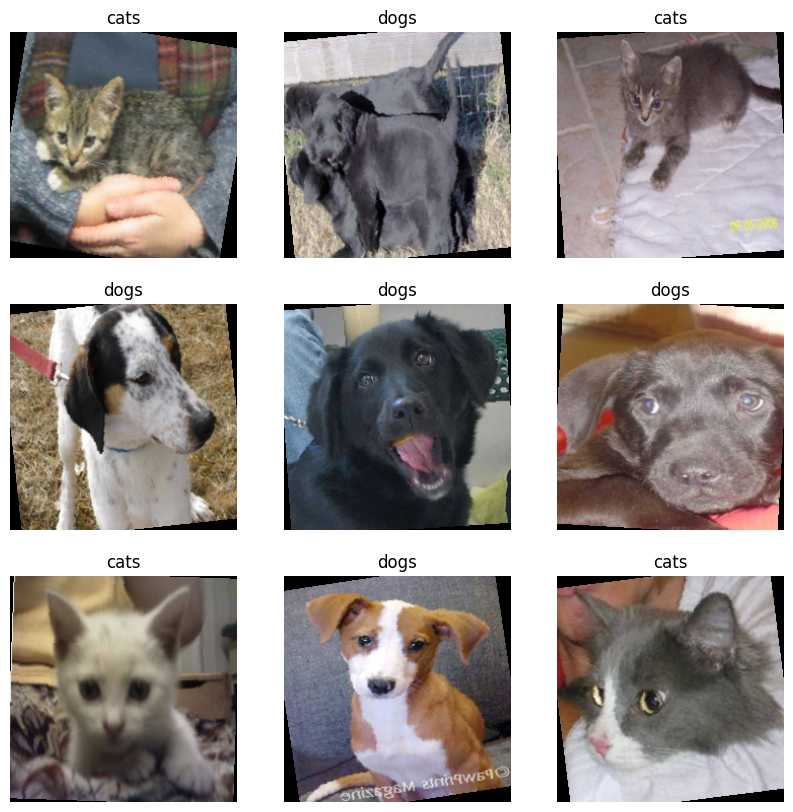

In [17]:
import matplotlib.pyplot as plt
import torch

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0)

    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])

    plt.imshow(img)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

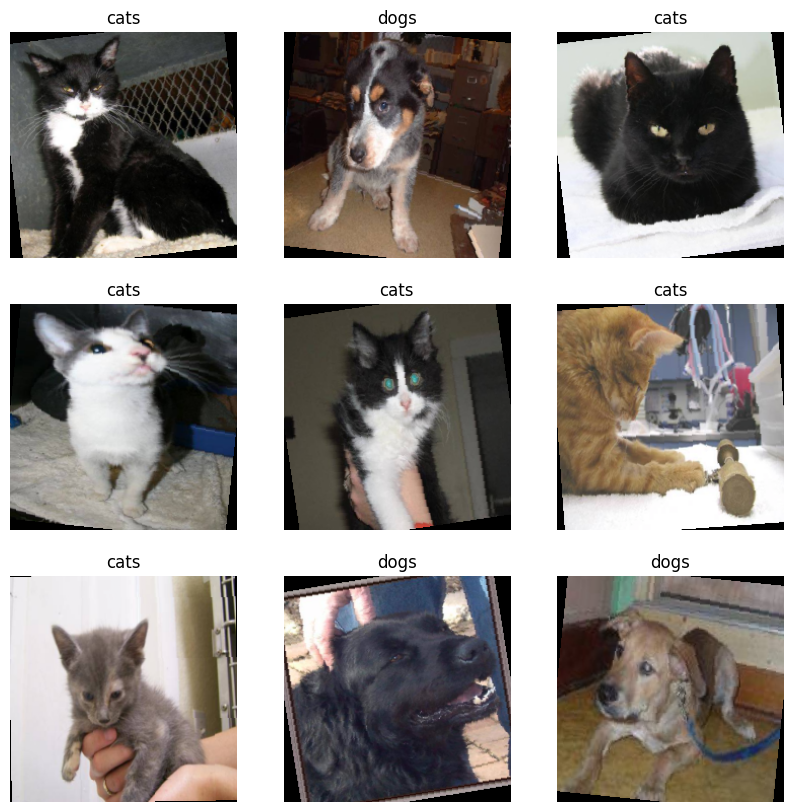

In [18]:
import matplotlib.pyplot as plt
import torch

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0)

    # De-normalize
    mean = torch.tensor([0.485,0.456,0.406])
    std = torch.tensor([0.229,0.224,0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.imshow(img)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

In [20]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import torch

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print("Only final layer will be trained.")

Only final layer will be trained.


In [22]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [23]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return epoch_loss, accuracy

In [24]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    loss, acc = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    train_losses.append(loss)
    train_accuracies.append(acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss = {loss:.4f}"
        f" | Accuracy = {acc:.2f}%"
    )

Epoch 1/5 | Loss = 0.1666 | Accuracy = 93.95%
Epoch 2/5 | Loss = 0.0989 | Accuracy = 96.13%
Epoch 3/5 | Loss = 0.0936 | Accuracy = 96.69%
Epoch 4/5 | Loss = 0.0999 | Accuracy = 96.04%
Epoch 5/5 | Loss = 0.0935 | Accuracy = 96.05%


In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 97.28%


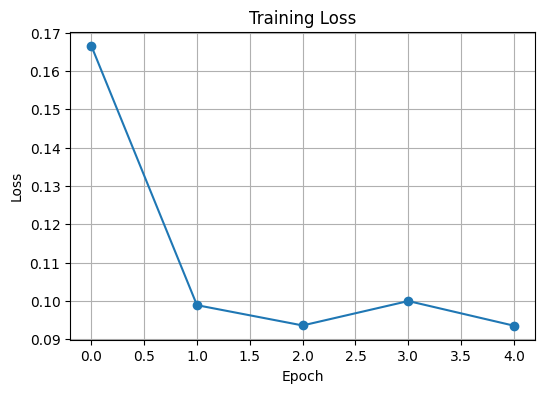

In [26]:
plt.figure(figsize=(6,4))

plt.plot(train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

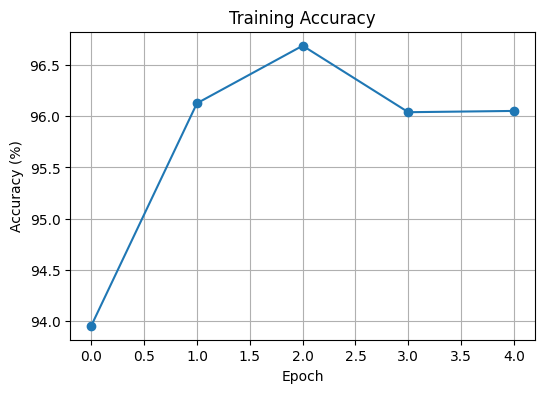

In [27]:
plt.figure(figsize=(6,4))

plt.plot(train_accuracies, marker="o")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [28]:
torch.save(
    model.state_dict(),
    "cats_vs_dogs_resnet18.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [29]:
from google.colab import files

files.download("cats_vs_dogs_resnet18.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cats vs Dogs Classification using ResNet18

## Model

ResNet18 (Pre-trained on ImageNet)

## Dataset

Cats vs Dogs Dataset

- Training Images: 8007
- Testing Images: 2025

## Data Augmentation

- Resize (224×224)
- Random Horizontal Flip
- Random Rotation
- Normalize

## Results

- Epochs: 5
- Final Training Accuracy: 96.05%
- Best Training Accuracy: 96.69%
- Test Accuracy:

## Key Learning

Transfer Learning with ResNet18 achieved high classification accuracy on a real-world image dataset by training only the final classification layer.

# Cats vs Dogs Classification using ResNet18

## Model

ResNet18 (Pre-trained on ImageNet)

## Dataset

Cats vs Dogs Dataset

- Training Images: 8007
- Testing Images: 2025

## Data Augmentation

- Resize (224×224)
- Random Horizontal Flip
- Random Rotation
- Normalize

## Results

- Epochs: 5
- Final Training Accuracy: 96.05%
- Best Training Accuracy: 96.69%
- Final Test Accuracy: 97.28%

## Key Learning

Transfer learning with a pre-trained ResNet18 model achieved high accuracy on a real-world image classification task by fine-tuning the final classification layer while reusing features learned from ImageNet.